In [1]:
# ===============================================================================
#    This sample illustrates how to grab and process images using the CInstantCamera class.
#    The images are grabbed and processed asynchronously, i.e.,
#    while the application is processing a buffer, the acquisition of the next buffer is done
#    in parallel.
#
#    The CInstantCamera class uses a pool of buffers to retrieve image data
#    from the camera device. Once a buffer is filled and ready,
#    the buffer can be retrieved from the camera object for processing. The buffer
#    and additional image data are collected in a grab result. The grab result is
#    held by a smart pointer after retrieval. The buffer is automatically reused
#    when explicitly released or when the smart pointer object is destroyed.
# ===============================================================================
from pypylon import pylon
from pypylon import genicam

import sys

In [33]:
import matplotlib.pyplot as plt

In [28]:
# Number of images to be grabbed.
countOfImagesToGrab = 5

In [3]:
# The exit code of the sample application.
exitCode = 0

In [4]:
# Create an instant camera object with the camera device found first.
tl_factory = pylon.TlFactory.GetInstance()

In [16]:
devices_info = [ ]
for i, device in enumerate( tl_factory.EnumerateDevices() ):
    devices.append( device )
    print( f"({i})", device.GetFullName() )

(0) Basler acA720-290gm#00305336CB66#169.254.103.203:3956


In [41]:
camera = pylon.InstantCamera( tl_factory.CreateDevice( devices[0] ) )

In [42]:
camera.Open()

In [43]:
# Print the model name of the camera.
print("Using device ", camera.GetDeviceInfo().GetModelName())

Using device  acA720-290gm


In [44]:
# demonstrate some feature access
new_width = camera.Width.Value - camera.Width.Inc
if new_width >= camera.Width.Min:
    camera.Width.Value = new_width

camera.Width.Value, camera.Width.Inc

(719, 1)

In [45]:
camera.Width.Value = 720

In [46]:
# https://docs.baslerweb.com/pylonapi/cpp/class_pylon_1_1_c_instant_camera
# this is the C++ API
# pypylon api is not known
type(camera)

pypylon.pylon.InstantCamera

In [52]:
# https://docs.baslerweb.com/exposure-mode
camera.ExposureMode.Value

'Timed'

In [47]:
# https://docs.baslerweb.com/exposure-time
camera.ExposureTimeAbs.Value

3000.0

In [49]:
camera.ExposureTimeMode.Value

'Standard'

In [51]:
camera.ExposureAuto.Value

'Off'

In [25]:
# The parameter MaxNumBuffer can be used to control the count of buffers
# allocated for grabbing. The default value of this parameter is 10.
camera.MaxNumBuffer.Value = 5

In [54]:
# https://docs.baslerweb.com/pixel-format
camera.PixelFormat.Value

# avaliable format for acA720-290gm 	
# Mono 8
# Mono 12
# Mono 12 Packed

'Mono12'

SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540
SizeX:  720 SizeY:  540


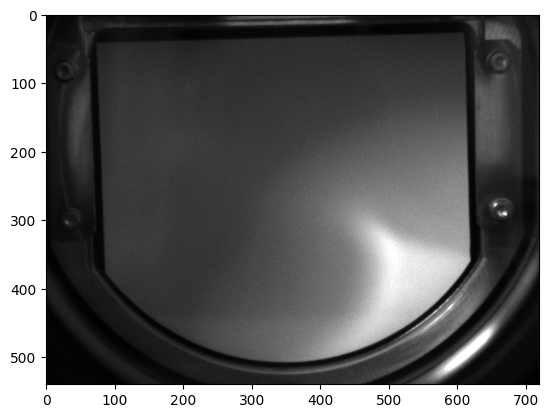

In [65]:
# Start the grabbing of c_countOfImagesToGrab images.
# The camera device is parameterized with a default configuration which
# sets up free-running continuous acquisition.
camera.StartGrabbingMax(countOfImagesToGrab)

# Camera.StopGrabbing() is called automatically by the RetrieveResult() method
# when c_countOfImagesToGrab images have been retrieved.
while camera.IsGrabbing():
    # Wait for an image and then retrieve it. A timeout of 5000 ms is used.
    grabResult = camera.RetrieveResult(5000, pylon.TimeoutHandling_ThrowException)

    # Image grabbed successfully?
    if grabResult.GrabSucceeded():
        # Access the image data.
        print("SizeX: ", grabResult.Width, "SizeY: ", grabResult.Height)
        img = grabResult.Array
        # print("Gray value of first pixel: ", img[0, 0])
    else:
        print("Error: ", grabResult.ErrorCode, grabResult.ErrorDescription)
    grabResult.Release()
plt.imshow(img, cmap="gray")

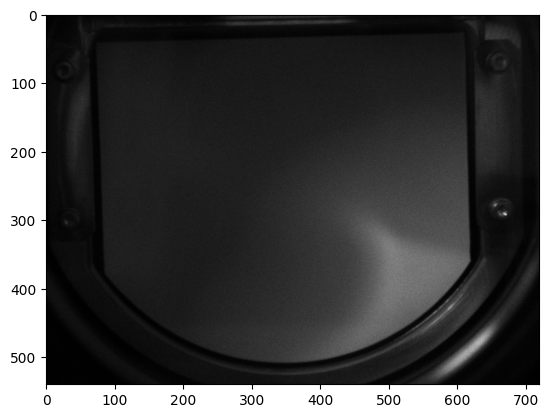

In [ ]:
camera.Close()